# Hybrid Strict Labelling Strategy
Using TA's non_stutter + Strict 3/3 Disfluencies

In [1]:

import os, glob, numpy as np, matplotlib.pyplot as plt
from src.data import DataManager
from sklearn.manifold import TSNE

manager = DataManager()
csv_paths = [
    'Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv',
    'Stuttering Events in Podcasts Dataset/fluencybank_labels.csv'
]
strict_dict = manager.generate_label_dict(csv_paths, strict=True)


[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).


In [2]:

# LOAD DATA
f_total = glob.glob('non_stutter/*.npy')
X_f = np.vstack([np.load(f) for f in f_total])
y_f = np.zeros(len(f_total))

d_total = glob.glob('data/features/disfluent/*.npy')
# Match keys: basenames without extension
d_files = [f for f in d_total if os.path.splitext(os.path.basename(f))[0] in strict_dict]

print(f'Fluent (TA): {len(y_f)}')
print(f'Stutter (Strict): {len(d_files)}')

X_d = np.vstack([np.load(f) for f in d_files])
y_d = np.ones(len(d_files))

X = np.vstack([X_f, X_d])
y = np.concatenate([y_f, y_d])


Fluent (TA): 6023
Stutter (Strict): 6668


Running visualization...


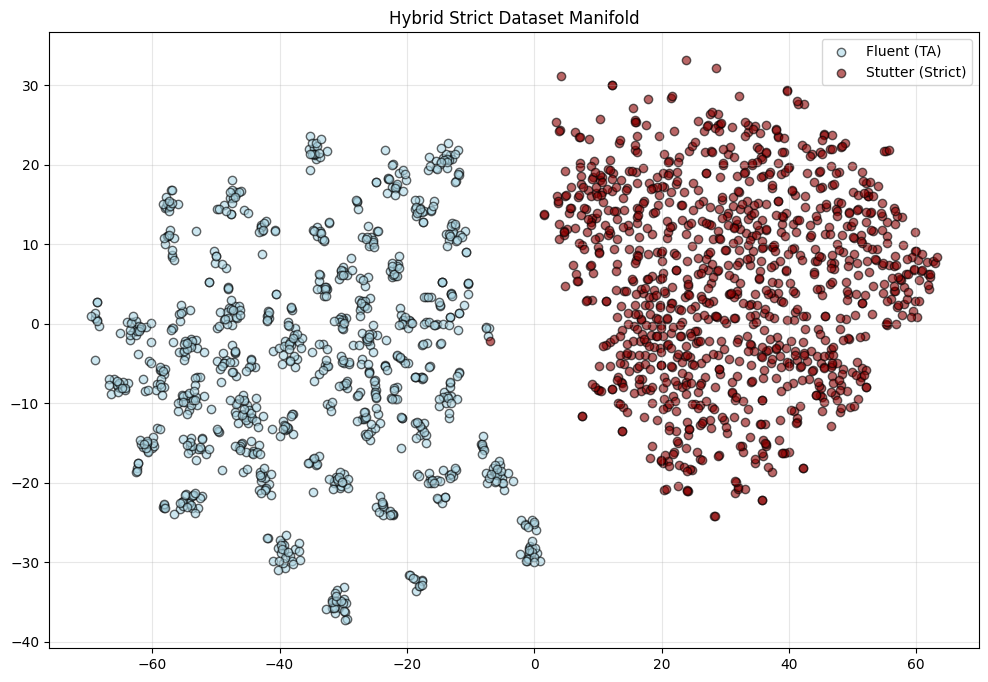

In [3]:

print('Running visualization...')
tsne = TSNE(n_components=2, init='pca', random_state=42)
idx = np.random.choice(len(X), 2000, replace=False)
X_2d = tsne.fit_transform(X[idx])
y_2d = y[idx]

plt.figure(figsize=(12, 8))
plt.scatter(X_2d[y_2d==0, 0], X_2d[y_2d==0, 1], c='lightblue', edgecolors='k', alpha=0.6, label='Fluent (TA)')
plt.scatter(X_2d[y_2d==1, 0], X_2d[y_2d==1, 1], c='darkred', edgecolors='k', alpha=0.6, label='Stutter (Strict)')
plt.title('Hybrid Strict Dataset Manifold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('hybrid_separation_final.png', dpi=300)
plt.show()
